<a href="https://colab.research.google.com/github/minhazmujaffar-art/data-analytics/blob/main/capstone_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Analysis of FHV Trip Records: Uber vs. Lyft Performance**

#Loading Data

In [1]:
import pandas as pd
df = pd.read_parquet("https://d37ci6vzurychx.cloudfront.net/trip-data/fhv_tripdata_2025-12.parquet")

In [2]:
df

,dispatching_base_num,pickup_datetime,dropOff_datetime,PUlocationID,DOlocationID,SR_Flag,Affiliated_base_number
0,B00111,2025-12-01 00:18:00,2025-12-01 00:35:00,NaN,NaN,NaN,B00111
1,B00111,2025-12-01 00:35:00,2025-12-01 00:53:00,NaN,NaN,NaN,B00111
2,B00112,2025-12-01 00:42:49,2025-12-01 01:09:21,NaN,14.0,NaN,B00112
3,B00171,2025-12-01 00:19:00,2025-12-01 00:29:00,68.0,107.0,NaN,B00256
4,B00221,2025-12-01 00:12:39,2025-12-01 00:19:54,NaN,243.0,NaN,B00221
...,...,...,...,...,...,...,...
1926886,B03659,2025-12-31 23:17:01,2025-12-31 23:35:05,NaN,240.0,NaN,B03404
1926887,B03659,2025-12-31 23:56:43,2026-01-01 00:00:01,NaN,220.0,NaN,B03404
1926888,B03659,2025-12-31 23:06:02,2025-12-31 23:20:45,NaN,127.0,NaN,B03404
1926889,B03659,2025-12-31 23:20:36,2025-12-31 23:38:53,NaN,47.0,NaN,B03404


In [3]:
### statistical analysis of the data
df.describe()

,pickup_datetime,dropOff_datetime,PUlocationID,DOlocationID,SR_Flag
count,1926891,1926891,367595.000000,1.644597e+06,0.0
mean,2025-12-15 09:15:00.481230,2025-12-15 10:59:12.985983,132.457531,1.333827e+02,NaN
min,2025-12-01 00:00:04,2025-12-01 00:03:33,1.000000,1.000000e+00,NaN
25%,2025-12-08 04:01:41,2025-12-08 05:23:11.500000,69.000000,6.900000e+01,NaN
50%,2025-12-14 22:37:56,2025-12-14 23:46:01,132.000000,1.320000e+02,NaN
75%,2025-12-22 16:56:40.500000,2025-12-22 18:07:41.500000,206.000000,2.080000e+02,NaN
max,2025-12-31 23:59:59,2026-12-31 15:39:00,265.000000,2.650000e+02,NaN
std,NaN,NaN,75.403425,7.819691e+01,NaN


In [4]:
print(df.columns.tolist())

['dispatching_base_num', 'pickup_datetime', 'dropOff_datetime', 'PUlocationID', 'DOlocationID', 'SR_Flag', 'Affiliated_base_number']


# Cleaning Data


In [5]:
import seaborn as sns

In [6]:
### cheaking all the null values
df.isnull()

,dispatching_base_num,pickup_datetime,dropOff_datetime,PUlocationID,DOlocationID,SR_Flag,Affiliated_base_number
0,False,False,False,True,True,True,False
1,False,False,False,True,True,True,False
2,False,False,False,True,False,True,False
3,False,False,False,False,False,True,False
4,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...
1926886,False,False,False,True,False,True,False
1926887,False,False,False,True,False,True,False
1926888,False,False,False,True,False,True,False
1926889,False,False,False,True,False,True,False


<Axes: >

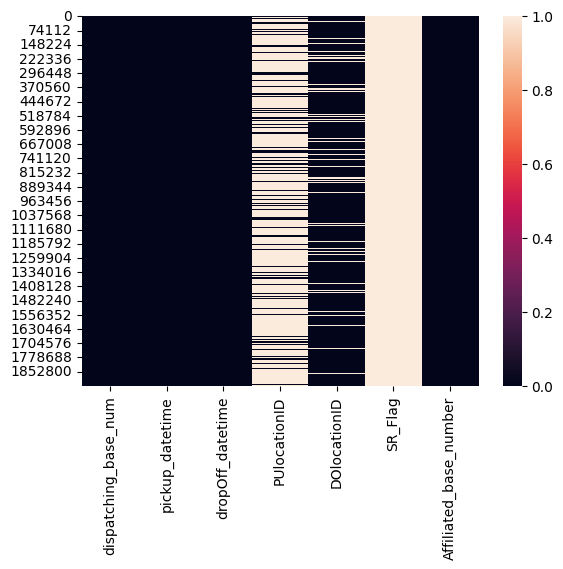

In [7]:
sns.heatmap(df.isnull())

In [8]:
df.isnull().sum()

,0
dispatching_base_num,0
pickup_datetime,0
dropOff_datetime,0
PUlocationID,1559296
DOlocationID,282294
SR_Flag,1926891
Affiliated_base_number,19


#EDA

In [9]:
### cleaning all the null values
df

,dispatching_base_num,pickup_datetime,dropOff_datetime,PUlocationID,DOlocationID,SR_Flag,Affiliated_base_number
0,B00111,2025-12-01 00:18:00,2025-12-01 00:35:00,NaN,NaN,NaN,B00111
1,B00111,2025-12-01 00:35:00,2025-12-01 00:53:00,NaN,NaN,NaN,B00111
2,B00112,2025-12-01 00:42:49,2025-12-01 01:09:21,NaN,14.0,NaN,B00112
3,B00171,2025-12-01 00:19:00,2025-12-01 00:29:00,68.0,107.0,NaN,B00256
4,B00221,2025-12-01 00:12:39,2025-12-01 00:19:54,NaN,243.0,NaN,B00221
...,...,...,...,...,...,...,...
1926886,B03659,2025-12-31 23:17:01,2025-12-31 23:35:05,NaN,240.0,NaN,B03404
1926887,B03659,2025-12-31 23:56:43,2026-01-01 00:00:01,NaN,220.0,NaN,B03404
1926888,B03659,2025-12-31 23:06:02,2025-12-31 23:20:45,NaN,127.0,NaN,B03404
1926889,B03659,2025-12-31 23:20:36,2025-12-31 23:38:53,NaN,47.0,NaN,B03404


In [10]:
df = df.dropna(subset=["PUlocationID","DOlocationID","Affiliated_base_number"])

In [11]:
df.isnull().sum()

,0
dispatching_base_num,0
pickup_datetime,0
dropOff_datetime,0
PUlocationID,0
DOlocationID,0
SR_Flag,367342
Affiliated_base_number,0


In [12]:
#### Drop column "SR_Flag"
df = df.drop(columns=["SR_Flag"])

# Creating A new Column based on Affiliated_Base_Number

In [13]:
df

,dispatching_base_num,pickup_datetime,dropOff_datetime,PUlocationID,DOlocationID,Affiliated_base_number
3,B00171,2025-12-01 00:19:00,2025-12-01 00:29:00,68.0,107.0,B00256
5,B00254,2025-12-01 00:23:39,2025-12-01 00:49:43,163.0,254.0,B03404
91,B00706,2025-12-01 00:01:12,2025-12-01 00:03:42,206.0,206.0,B00706
92,B00706,2025-12-01 00:10:36,2025-12-01 00:23:29,206.0,187.0,B00706
93,B00706,2025-12-01 00:59:21,2025-12-01 01:05:54,187.0,206.0,B00706
...,...,...,...,...,...,...
1926836,B03284,2025-12-31 23:36:33,2026-01-01 00:02:57,140.0,51.0,
1926837,B03284,2025-12-31 23:03:54,2025-12-31 23:47:04,17.0,262.0,
1926838,B03284,2025-12-31 23:19:45,2026-01-01 00:36:21,52.0,254.0,
1926847,B03331,2025-12-31 23:13:24,2025-12-31 23:24:40,173.0,173.0,B03331


In [14]:
df["Affiliated_base_number"].unique()

array(['B00256', 'B03404', 'B00706', 'b03404', 'b03331', 'b01066',
       'B01367', 'B01087', 'B03394', 'B01413', 'B02749', 'B02111',
       'B00449', 'B02944', 'B03113', 'B03250', 'B02932', 'B03266', '',
       'B02127', 'B03331         ', 'B03572         ', 'B03646         ',
       'B02613', 'B00965', 'B02930', 'B02856', 'B00972', 'b03171',
       'B01452', 'B03236', 'B02536', 'B02661', 'B03046', 'B03152',
       'B03288', 'B03721', 'B02429', 'B03147', 'b03239', 'B01288',
       'B01364         ', 'B03240', 'B03304', 'B00446', 'B02787',
       'B01710', 'B01995         ', 'B03279', 'B02254', 'B02803',
       'B03128', 'B00111', 'B03455', 'B03470', 'B03682', 'B00254',
       'B02664', 'B03621', 'B02243', 'B02987', 'B03407', 'B03604',
       'B03467', 'B03040', 'B03320', 'B03228', 'B02550', 'B03723',
       'B00559', 'B00906', 'b03259', 'B02926', 'B03538', 'B03396',
       'B03640', 'B03209', 'B03595', 'B03298         ', 'B02822',
       'B03560', 'B03064', 'B03181', 'B03120', 'B03557

In [26]:
### a function to apply to every row to create a column named "base_category"
def classify_base(base):

    base = str(base).upper().strip()


    if base.startswith(('B00', 'B01', 'B02512', 'B02875', 'B03404')):
        return 'Uber'


    elif base.startswith(('B02844', 'B02864', 'B02510')):
        return 'Lyft'


    elif base.startswith(('B02', 'B03')):
        return 'Lyft'





In [ ]:
unique_bases = df['Affiliated_base_number'].unique()
base_map = {b: classify_base(b) for b in unique_bases}
df['base_category'] = df['Affiliated_base_number'].map(base_map)
print(df['base_category'].value_counts())

base_category
Uber    135837
Lyft     90941
Name: count, dtype: int64


In [16]:
unique_bases = df['Affiliated_base_number'].unique()
base_map = {b: classify_base(b) for b in unique_bases}
df['base_category'] = df['Affiliated_base_number'].map(base_map)
print(df['base_category'].value_counts())

base_category
Uber    135837
Lyft     90941
Name: count, dtype: int64


In [17]:
df.isnull().sum()

,0
dispatching_base_num,0
pickup_datetime,0
dropOff_datetime,0
PUlocationID,0
DOlocationID,0
Affiliated_base_number,0
base_category,140564


In [18]:
### droping all the null values from the "base_category"
df = df.dropna(subset=["base_category"])

In [19]:
df

,dispatching_base_num,pickup_datetime,dropOff_datetime,PUlocationID,DOlocationID,Affiliated_base_number,base_category
3,B00171,2025-12-01 00:19:00,2025-12-01 00:29:00,68.0,107.0,B00256,Uber
5,B00254,2025-12-01 00:23:39,2025-12-01 00:49:43,163.0,254.0,B03404,Uber
91,B00706,2025-12-01 00:01:12,2025-12-01 00:03:42,206.0,206.0,B00706,Uber
92,B00706,2025-12-01 00:10:36,2025-12-01 00:23:29,206.0,187.0,B00706,Uber
93,B00706,2025-12-01 00:59:21,2025-12-01 01:05:54,187.0,206.0,B00706,Uber
...,...,...,...,...,...,...,...
1926805,B03266,2025-12-31 23:17:07,2025-12-31 23:27:05,179.0,7.0,B03266,Lyft
1926806,B03266,2025-12-31 23:04:46,2025-12-31 23:14:22,179.0,179.0,B03266,Lyft
1926807,B03266,2025-12-31 23:24:55,2025-12-31 23:33:11,7.0,7.0,B03266,Lyft
1926847,B03331,2025-12-31 23:13:24,2025-12-31 23:24:40,173.0,173.0,B03331,Lyft


#Plotting the data

<Axes: xlabel='base_category'>

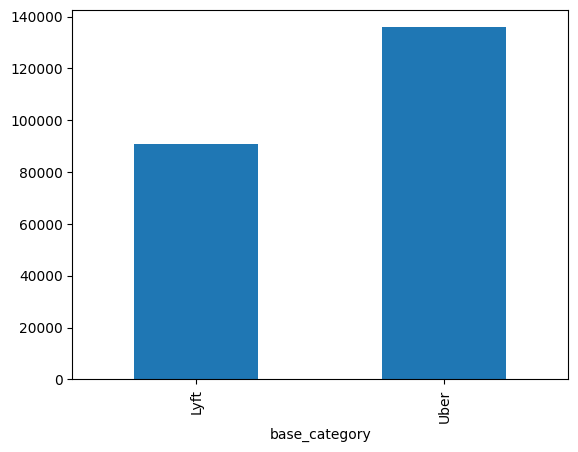

In [20]:
### creating a plot to see all the trips
df.groupby("base_category")["PUlocationID"].count().plot(kind="bar")

#Based on this visual, Uber accounts for roughly 60% of the total data shown, while Lyft accounts for about 40%

In [21]:
df.isnull().sum()

,0
dispatching_base_num,0
pickup_datetime,0
dropOff_datetime,0
PUlocationID,0
DOlocationID,0
Affiliated_base_number,0
base_category,0


# Ploting the data

In [22]:
import seaborn as sns

In [23]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['date'] = df['pickup_datetime'].dt.date
df = df.set_index("date")

/tmp/ipykernel_16213/989152761.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
/tmp/ipykernel_16213/989152761.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date'] = df['pickup_datetime'].dt.date


In [24]:
df

,dispatching_base_num,pickup_datetime,dropOff_datetime,PUlocationID,DOlocationID,Affiliated_base_number,base_category
date,,,,,,,
2025-12-01,B00171,2025-12-01 00:19:00,2025-12-01 00:29:00,68.0,107.0,B00256,Uber
2025-12-01,B00254,2025-12-01 00:23:39,2025-12-01 00:49:43,163.0,254.0,B03404,Uber
2025-12-01,B00706,2025-12-01 00:01:12,2025-12-01 00:03:42,206.0,206.0,B00706,Uber
2025-12-01,B00706,2025-12-01 00:10:36,2025-12-01 00:23:29,206.0,187.0,B00706,Uber
2025-12-01,B00706,2025-12-01 00:59:21,2025-12-01 01:05:54,187.0,206.0,B00706,Uber
...,...,...,...,...,...,...,...
2025-12-31,B03266,2025-12-31 23:17:07,2025-12-31 23:27:05,179.0,7.0,B03266,Lyft
2025-12-31,B03266,2025-12-31 23:04:46,2025-12-31 23:14:22,179.0,179.0,B03266,Lyft
2025-12-31,B03266,2025-12-31 23:24:55,2025-12-31 23:33:11,7.0,7.0,B03266,Lyft


<Axes: xlabel='date', ylabel='count'>

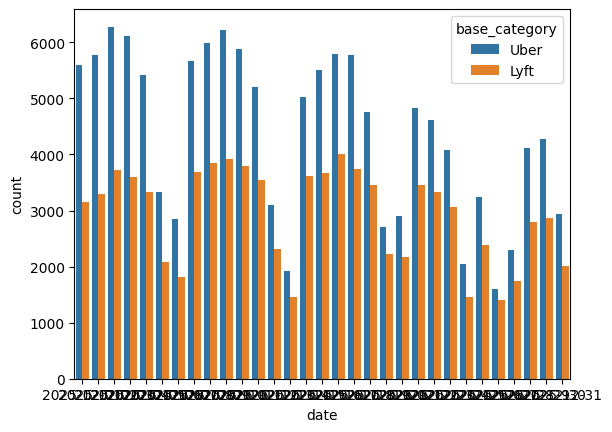

In [25]:
### creating a plot to compaire all trips on daily basis
sns.countplot(data = df, x= "date", hue = "base_category")

#Uber consistently has a higher ride volume than Lyft every single day throughout the month.

#Conclusion

# The project successfully converted a massive, "dirty" dataset into a clean analytical model. The combination of targeted data cleaning and feature engineering allowed for a robust statistical comparison, proving that the NYC FHV market remains highly stratified by base affiliation operated by UBER.